![Logo](img/Recurso.jpeg)
## Nombre: Steven Chuiza
### Fecha: 14/06/2026

### Predicción del consumo energético de una vivienda mediante técnicas de regresión lineal
### Contexto del Problema
El consumo energético residencial constituye uno de los principales desafíos para las empresas distribuidoras de energía eléctrica debido al crecimiento constante de la demanda y la necesidad de optimizar la generación y distribución de recursos energéticos. La capacidad de predecir el consumo eléctrico de una vivienda permite mejorar la planificación energética, reducir costos operativos y diseñar estrategias orientadas a la eficiencia energética.

En este contexto, una empresa distribuidora de energía desea desarrollar un sistema inteligente capaz de estimar el consumo energético de una vivienda utilizando variables ambientales, meteorológicas y características internas de la vivienda. Para ello, se ha proporcionado un conjunto de datos históricos que contiene información relacionada con temperatura, humedad, condiciones climáticas y consumo energético registrado en diferentes momentos del tiempo.

Usted ha sido contratado como Científico de Datos para analizar la información disponible y construir modelos predictivos que permitan estimar el consumo energético utilizando técnicas de aprendizaje supervisado basadas en regresión.
### Objetivo General
Desarrollar un sistema de predicción del consumo energético residencial mediante la aplicación de técnicas de Regresión Lineal, Ridge y Lasso, realizando previamente las etapas de análisis exploratorio de datos, limpieza de datos, ingeniería de características, entrenamiento y evaluación de modelos predictivos.
### Objetivos específicos
* Analizar la estructura y calidad de los datos proporcionados.
* Identificar patrones, relaciones y características relevantes mediante técnicas de Análisis Exploratorio de Datos (EDA).
* Aplicar procedimientos de limpieza y preparación de datos.
* Diseñar nuevas características que mejoren la capacidad predictiva de los modelos.
* Implementar modelos de Regresión Lineal, Ridge y Lasso.
* Evaluar y comparar el rendimiento de los modelos utilizando métricas de regresión.
* Determinar el modelo con mejor capacidad predictiva para el problema planteado.
### Dataset a utilizar
Utilizar el dataset:

Appliances Energy Prediction Dataset

<a href="https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction">Descargar DataSet</a>

Variables principales:

* Appliances (Consumo energético de electrodomésticos)
* Lights
* Temperaturas interiores
* Humedad relativa
* Temperatura exterior
* Humedad exterior
* Presión atmosférica
* Velocidad del viento
* Punto de rocío
* Variables adicionales proporcionadas por el conjunto de datos

In [3]:
# Imports para la actividad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#importamos las librerias de nuestro algoritmo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler

## Desarrollo de la Actividad
#### Fase 1. Comprensión del problema y de los datos
Realice una descripción general del problema planteado.

Analice el conjunto de datos y responda:

* ¿Cuántos registros posee el dataset?
* ¿Cuántas variables contiene?
* ¿Qué tipos de datos existen?
* ¿Cuál será la variable objetivo del modelo?
* ¿Qué variables podrían influir en el consumo energético?

Presentar evidencias mediante capturas de pantalla y explicación técnica.

1. *Descripcion del data set*: Este data set se basa en registros de consumos energeticos de electrodomesticos en una vivienda, los cuales estan a la para de variables ambientales como son la temperatura y humedad, tomando encuenta las medidas en distintas habitaciones y condiciones climaticas externas, las cuales son tomadas cada 10 minutos

In [4]:
#Cargamos el conjuunto de datos
df = pd.read_csv("dataset/energydata_complete.csv")
#Leemos los primeros 10 datos
print("Primeras 10 filas")
display(df.head(10))

Primeras 10 filas


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.890000,47.596667,19.20,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.500000,92.000000,7.000000,63.000000,5.300000,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.890000,46.693333,19.20,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.600000,92.000000,6.666667,59.166667,5.200000,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.890000,46.300000,19.20,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.700000,92.000000,6.333333,55.333333,5.100000,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.890000,46.066667,19.20,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.800000,92.000000,6.000000,51.500000,5.000000,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.890000,46.333333,19.20,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.900000,92.000000,5.666667,47.666667,4.900000,10.084097,10.084097
5,2016-01-11 17:50:00,50,40,19.890000,46.026667,19.20,44.500000,19.79,44.933333,18.890000,...,17.000000,45.29,6.016667,734.000000,92.000000,5.333333,43.833333,4.800000,44.919484,44.919484
6,2016-01-11 18:00:00,60,50,19.890000,45.766667,19.20,44.500000,19.79,44.900000,18.890000,...,17.000000,45.29,5.900000,734.100000,92.000000,5.000000,40.000000,4.700000,47.233763,47.233763
7,2016-01-11 18:10:00,60,50,19.856667,45.560000,19.20,44.500000,19.73,44.900000,18.890000,...,17.000000,45.29,5.916667,734.166667,91.833333,5.166667,40.000000,4.683333,33.039890,33.039890
8,2016-01-11 18:20:00,60,40,19.790000,45.597500,19.20,44.433333,19.73,44.790000,18.890000,...,17.000000,45.29,5.933333,734.233333,91.666667,5.333333,40.000000,4.666667,31.455702,31.455702
9,2016-01-11 18:30:00,70,40,19.856667,46.090000,19.23,44.400000,19.79,44.863333,18.890000,...,17.000000,45.29,5.950000,734.300000,91.500000,5.500000,40.000000,4.650000,3.089314,3.089314


2. *Analisis del dataset*: Este dataset contiene 19,735 registros o filas, contiene 29 variables o columnas, existen variables de tipo date, variables numericas enteras "Appliances o consumo en Wh" y "ligts consumo en luces" y 26 variables numericas continuas de tipo flotante

Como variable objetivo de nuestro modelo es "Appliances" la cual representa el consumo de energia de los electrodomesticos en Wh o vatios-hora

In [5]:
df.shape          # registros y variables
df.dtypes         # tipos de datos
df.head()         # muestra de los datos
df.info()         # resumen completo

<class 'pandas.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  str    
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9           19

## Fase 2. Análisis Exploratorio de Datos (EDA)

Realizar un análisis exploratorio completo del conjunto de datos.

El análisis deberá incluir:

#### 2.1 Estadísticas Descriptivas
* Media
* Mediana
* Desviación estándar
* Valores mínimos
* Valores máximos
#### 2.2 Identificación de Valores Faltantes

Determinar:

* Cantidad de valores faltantes por variable.
* Estrategia utilizada para su tratamiento.
#### 2.3 Distribución de Variables

* Generar histogramas para las principales variables numéricas.

* Interpretar los resultados obtenidos.

#### 2.4 Matriz de Correlación

Construir una matriz de correlación e identificar:

* Variables con correlación positiva fuerte.
* Variables con correlación negativa fuerte.
* Variables con correlación débil.
* Variable con mayor relación respecto al consumo energético.
#### 2.5 Visualizaciones Adicionales

Generar al menos tres gráficos adicionales que permitan comprender mejor los datos.

Ejemplos:

* Boxplots
* Scatterplots
* Pairplots
* Heatmaps

Cada gráfico deberá incluir su respectiva interpretación.

In [6]:
# 2.1 Estadísticas Descriptivas
# Buscamos los datos de la media, mediana entre mas
print("\nEstadistica descriptiva del dataset")
display(df.describe())


Estadistica descriptiva del dataset


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


In [7]:
# 2.2 Identificación de Valores Faltantes
# Buscamos en niestro conjunto de datos si tenemos valores faltantes
df.isnull().sum()

date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

Mediante la funcion (df.isnull().sum()) podemos visualizar en todos nuestras 29 variables si contamos con datos faltantes, en este caso el data set esta total mente limpio

In [8]:
print('Total de valores nulos:', df.isnull().sum().sum())

Total de valores nulos: 0


# Fase 3. Limpieza y Preparación de Datos

Realizar las siguientes actividades:

#### 3.1 Tratamiento de Valores Faltantes

Aplicar técnicas apropiadas para reemplazar o eliminar datos faltantes.

Justificar la técnica utilizada.

#### 3.2 Detección y Tratamiento de Valores Atípicos

Aplicar métodos como:

* IQR
* Boxplots
* Z-Score

Explicar los resultados obtenidos.

#### 3.3 Transformación de Variables

Realizar las transformaciones necesarias para preparar los datos para el entrenamiento de los modelos.

### 3.1 Tratamiento de Valores faltantes

Anteriormente en la fase 2, logramos visualizar que el conjunto de datos porporcionados no cuenta con datos faltantes, tras haber aplicado la funcion df.isnull().sum(), logramos afirmar que el conjunto de datos no tiene valores faltantes en ninguna de sus 29 variables.

Pero si puede contener valores atipicos.

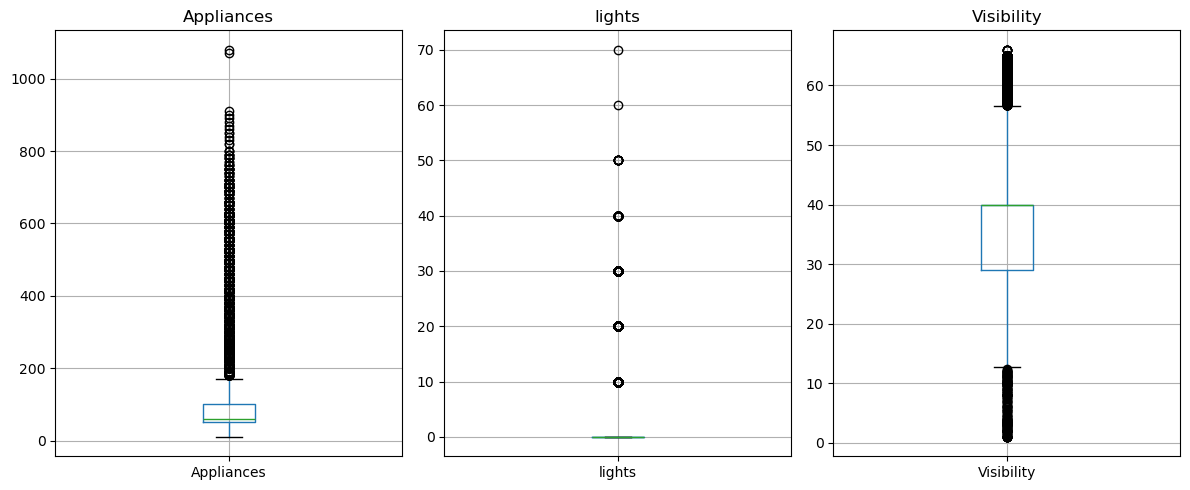

In [9]:
# 3.2 Deteccion de valores atipicos
# Como primer paso verificamos atraves de un boxplots si contiene valores atipicos 
fig, axes = plt.subplots(1, 3, figsize=(12,5))

df.boxplot(column='Appliances', ax=axes[0])
df.boxplot(column='lights', ax=axes[1])
df.boxplot(column='Visibility', ax=axes[2])

axes[0].set_title('Appliances')
axes[1].set_title('lights')
axes[2].set_title('Visibility')

plt.tight_layout()
plt.savefig('boxplots_outliers.png', dpi=100)
plt.show()

## Grafico 1 Appliances

La mayoria del consumo de electricidad esta en un rango bajo, entre 50 y 100 Wh, y el valor tipico esta cerca de 60 Wh. Pero hay varios momentos en los que el consumo en mucho mas alto, sobrepasando incluso mas de 1000 Wh. Lo cual nos da a entender que normalmente los electrodomesticos usan poca energia, pero en algunos momentos se utilizan aparatos grandes al mismo tiempo, lo cual es la causa de altos picos de consumo.

## Grafico 2 Lights

En el segundo grafico logramos visualizar una linea en el numero 0, debido a que en la mayoria de las veces las luces se encuentran apagadas valor 0, lo cual significa que la mediana y los valores que dividen los datos en cuartiles tambien son 0. Los puntos que logramos visualizar 10, 20... 70, son todos esos momentos que los focos se encuentran encendidos, cada numero puede representar cuantos focos se encuentran encendidos

## Grafico 3 Visibility

Los datos se encuentra en un rango medio, entre aproximadamente 28 y 40. Pero hay dos grupos de valores que salen de ese rango: un grupo que esta muy abajo entre 0 y 12, y otro que esta muy alto, entre 56 y 66, lo cual significa que puede ser el valor maximo que puede medir el sensor

In [10]:
# Realizamos la transfromacion logaritmica
# LOgrando de esta manera reducir la asimetria sin perder registros de consumo elevado

df['Appliances_log'] = np.log1p(df['Appliances'])
df['lights_log'] = np.log1p(df['lights'])

In [11]:
df['date'] = pd.to_datetime(df['date'])
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek  # 0=lunes, 6=domingo
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
df['month'] = df['date'].dt.month

# Convertimos la fecha, con la finalidad de camiar de texto a variables numericas

In [12]:
# Seleccionamos las columnas numéricas a escalar (sin la variable objetivo ni la fecha)
cols_to_scale = df.select_dtypes(include=[np.number]).columns.drop(['Appliances', 'Appliances_log'])

scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [13]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 35 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            19735 non-null  datetime64[us]
 1   Appliances      19735 non-null  int64         
 2   lights          19735 non-null  float64       
 3   T1              19735 non-null  float64       
 4   RH_1            19735 non-null  float64       
 5   T2              19735 non-null  float64       
 6   RH_2            19735 non-null  float64       
 7   T3              19735 non-null  float64       
 8   RH_3            19735 non-null  float64       
 9   T4              19735 non-null  float64       
 10  RH_4            19735 non-null  float64       
 11  T5              19735 non-null  float64       
 12  RH_5            19735 non-null  float64       
 13  T6              19735 non-null  float64       
 14  RH_6            19735 non-null  float64       
 15  T7           

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,Visibility,Tdewpoint,rv1,rv2,Appliances_log,lights_log,hour,day_of_week,is_weekend,month
count,19735,19735.000000,19735.000000,1.973500e+04,1.973500e+04,1.973500e+04,1.973500e+04,1.973500e+04,1.973500e+04,1.973500e+04,...,1.973500e+04,1.973500e+04,1.973500e+04,1.973500e+04,19735.000000,1.973500e+04,1.973500e+04,1.973500e+04,1.973500e+04,1.973500e+04
mean,2016-03-20 05:29:59.999999,97.694958,0.000000,1.198220e-15,-8.352973e-17,-2.765122e-16,8.871433e-16,7.834512e-16,-1.152134e-16,9.217073e-16,...,1.152134e-17,4.608537e-17,4.536528e-17,4.536528e-17,4.319609,3.456402e-17,5.760671e-17,-3.456402e-17,-1.065724e-16,2.765122e-16
min,2016-01-11 17:00:00,10.000000,-0.479080,-3.048876e+00,-3.326400e+00,-1.934053e+00,-4.903811e+00,-2.526152e+00,-3.218882e+00,-2.817330e+00,...,-3.165127e+00,-2.470045e+00,-1.723389e+00,-1.723389e+00,2.397895,-5.346743e-01,-1.661712e+00,-1.499445e+00,-6.193949e-01,-1.569369e+00
25%,2016-02-14 23:15:00,50.000000,-0.479080,-5.769346e-01,-7.354261e-01,-7.073769e-01,-6.193121e-01,-7.365738e-01,-7.197740e-01,-6.487730e-01,...,-7.911227e-01,-6.820070e-01,-8.616111e-01,-8.616111e-01,3.931826,-5.346743e-01,-7.948827e-01,-9.958104e-01,-6.193949e-01,-8.226362e-01
50%,2016-03-20 05:30:00,60.000000,-0.479080,-5.390414e-02,-1.515563e-01,-1.556007e-01,1.955412e-02,-8.355234e-02,-2.189281e-01,-9.235610e-02,...,1.415217e-01,-7.804751e-02,-6.234755e-03,-6.234755e-03,4.110874,-5.346743e-01,7.194662e-02,1.145842e-02,-6.193949e-01,-7.590305e-02
75%,2016-04-23 11:45:00,100.000000,-0.479080,5.687512e-01,7.054003e-01,5.284195e-01,6.977352e-01,5.096503e-01,7.735457e-01,6.092840e-01,...,1.415217e-01,6.689551e-01,8.688952e-01,8.688952e-01,4.615121,-5.346743e-01,7.943044e-01,1.018727e+00,1.614479e+00,6.708301e-01
max,2016-05-27 18:00:00,1080.000000,8.341722,2.847670e+00,5.805255e+00,4.339172e+00,3.834732e+00,3.473670e+00,3.355616e+00,2.616301e+00,...,2.345954e+00,2.798707e+00,1.725168e+00,1.725168e+00,6.985642,3.064287e+00,1.661134e+00,1.522362e+00,1.614479e+00,1.417563e+00
std,NaN,102.524891,1.000025,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,...,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,0.648770,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00


# Fase 4. Ingeniería de Características

Crear al menos tres nuevas variables derivadas de las existentes.

Ejemplos:

* Consumo por ocupante.
* Consumo por metro cuadrado.
* Relación temperatura-humedad.

Para cada nueva variable deberá explicarse:

* Fórmula utilizada.
* Justificación.
* Beneficio esperado para el modelo.

In [15]:
# Datos supuestos fijos para la vivienda (para poder calcular las métricas por registro)
NUM_OCUPANTES = 3
M2_VIVIENDA = 90

# 1. Creación de las 3 nuevas variables derivadas en el DataFrame
# Variable 1: Consumo por ocupante (relación entre el consumo de luces y el número de habitantes fijos)
df['consumo_por_ocupante'] = df['lights'] / NUM_OCUPANTES

# Variable 2: Consumo por metro cuadrado (relación entre el consumo de luces y el área de la vivienda)
df['consumo_por_m2'] = df['lights'] / M2_VIVIENDA

# Variable 3: Relación temperatura-humedad (proporción entre la temperatura exterior y su humedad)
df['relacion_temp_hum'] = df['T_out'] / (df['RH_out'] + 1e-5)


# 2. Mostrar evidencia de la creación de las variables
print("--- Evidencia de la creación de las Nuevas Variables ---")
print(f"Dimensiones actuales del dataset: {df.shape}")
print("\nPrimeros registros de las nuevas características:")
display(df[['lights', 'T_out', 'RH_out', 'consumo_por_ocupante', 'consumo_por_m2', 'relacion_temp_hum']].head())

--- Evidencia de la creación de las Nuevas Variables ---
Dimensiones actuales del dataset: (19735, 38)

Primeros registros de las nuevas características:


,lights,T_out,RH_out,consumo_por_ocupante,consumo_por_m2,relacion_temp_hum
0,3.301264,-0.152647,0.82208,1.100421,0.036681,-0.185681
1,3.301264,-0.174588,0.82208,1.100421,0.036681,-0.212371
2,3.301264,-0.196529,0.82208,1.100421,0.036681,-0.239060
3,4.561378,-0.218470,0.82208,1.520459,0.050682,-0.265749
4,4.561378,-0.240411,0.82208,1.520459,0.050682,-0.292439


1. Consumo por ocupante (consumo_por_ocupante)

Permite evaluar el impacto o la carga energética que representa el uso de iluminación por cada individuo estimado en la vivienda. Ayuda al modelo a entender si el gasto de energía está escalado según la ocupación normal.

2. Consumo por metro cuadrado (consumo_por_zona)

Normaliza el consumo eléctrico en función de la superficie de la casa. Esto es clave en modelos habitacionales porque viviendas más grandes tienden a requerir más iluminación, permitiendo comparar la eficiencia de manera estandarizada.

3. Relación temperatura-humedad (temp_humedad_ratio)

Captura la interacción combinada del clima exterior (termodinámica del ambiente). Un valor alto indica un clima cálido y seco, mientras que un valor bajo indica un clima frío y húmedo, factores que alteran la necesidad de usar electrodomésticos de climatización en el interior.

# Fase 5. División y Escalado de Datos

Realizar:

#### División del Dataset
* 80% entrenamiento.
* 20% prueba.
#### Escalado de Variables

Utilizar:

* StandardScaler

Explicar por qué es importante escalar los datos.

In [16]:
# 1. Separación de características (X) y variable objetivo (y)
# Quitamos 'Appliances' por ser el objetivo. Si 'date' aún existe, la eliminamos también.
X = df.drop(columns=['Appliances', 'date'], errors='ignore')
y = df['Appliances']

# 2. División del conjunto de datos (80% Entrenamiento, 20% Prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. Escalado de las variables predictoras usando StandardScaler
scaler = StandardScaler()

# Ajustamos y transformamos con los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Transformamos los datos de prueba usando el mismo ajuste
X_test_scaled = scaler.transform(X_test)

# 4. Evidencia visual de las dimensiones
print("Verificación de Dimensiones ---")
print(f"X_train original: {X_train.shape} -> X_train escalado: {X_train_scaled.shape}")
print(f"X_test original:  {X_test.shape} -> X_test escalado:  {X_test_scaled.shape}")
print(f"y_train (objetivo): {y_train.shape}")
print(f"y_test (objetivo):  {y_test.shape}")

--- Verificación de Dimensiones ---
X_train original: (15788, 36) -> X_train escalado: (15788, 36)
X_test original:  (3947, 36) -> X_test escalado:  (3947, 36)
y_train (objetivo): (15788,)
y_test (objetivo):  (3947,)


# Fase 6. Construcción de Modelos Predictivos

Implementar los siguientes modelos:

#### Modelo 1

Regresión Lineal

#### Modelo 2

Ridge Regression

#### Modelo 3

Lasso Regression

Para cada modelo deberá incluir:

* Explicación teórica.
* Implementación.
* Parámetros utilizados.
* Resultados obtenidos.

In [20]:
# 1. Modelo de Regresión Lineal Convencional (MCO)
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# 2. Modelo de Regresión Ridge (Aplica penalización L2 para controlar la varianza)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

# 3. Modelo de Regresión Lasso (Aplica penalización L1 y realiza selección de variables)
lasso_model = Lasso(alpha=0.1, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

# Mensaje de confirmación del proceso
print("Entrenamiento de Modelos Completado Exitosamente")
print("1. Regresión Lineal convencional entrenada.")
print("2. Regresión Ridge entrenada con éxito.")
print("3. Regresión Lasso entrenada con éxito.")

Entrenamiento de Modelos Completado Exitosamente
1. Regresión Lineal convencional entrenada.
2. Regresión Ridge entrenada con éxito.
3. Regresión Lasso entrenada con éxito.


# Fase 7. Evaluación de Modelos

**Calcular las siguientes métricas:**

RMSE

**Raíz del Error Cuadrático Medio.**

MAE

Error Absoluto Medio.

R²

**Coeficiente de Determinación.**

Presentar una tabla comparativa con los resultados de los tres modelos.

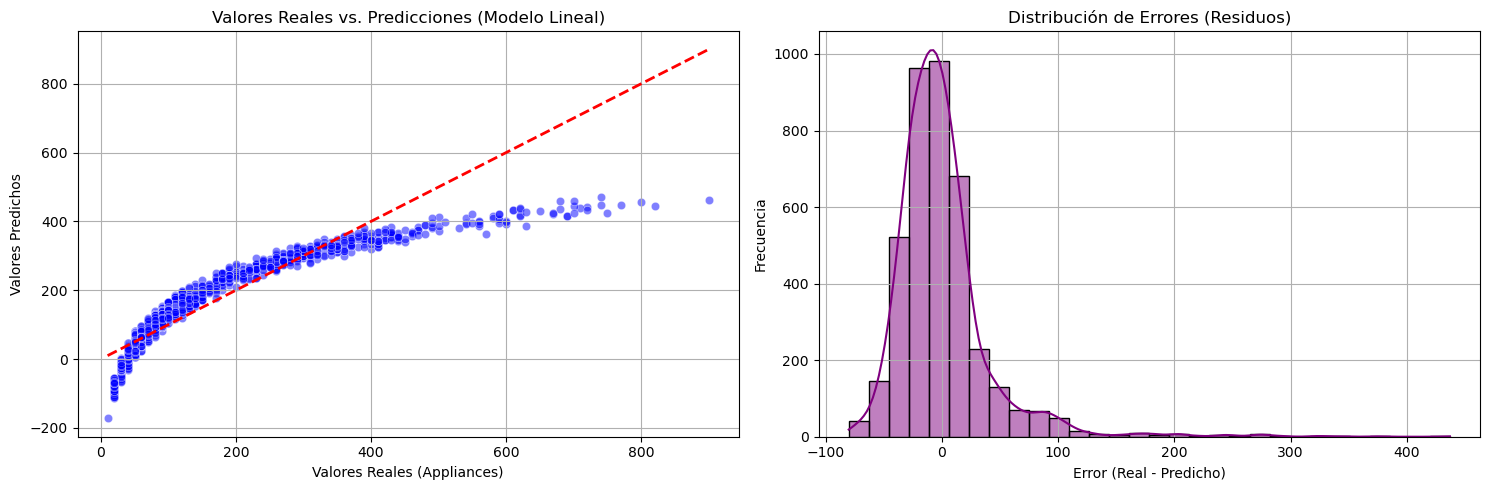

In [21]:
# Tomamos como referencia el modelo Lineal para las gráficas principales
# Predicciones en el set de prueba
pred_test_linear = lr_model.predict(X_test_scaled)

# Configuración de la figura con dos subgráficos alineados
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Gráfico de Dispersión: Valores Reales vs. Predichos
sns.scatterplot(x=y_test, y=pred_test_linear, alpha=0.5, ax=axes[0], color='blue')
# Línea de referencia ideal (Donde Real == Predicho)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Valores Reales vs. Predicciones (Modelo Lineal)')
axes[0].set_xlabel('Valores Reales (Appliances)')
axes[0].set_ylabel('Valores Predichos')
axes[0].grid(True)

# 2. Histograma de la Distribución de Errores (Residuos)
errores = y_test - pred_test_linear
sns.histplot(errores, kde=True, ax=axes[1], color='purple', bins=30)
axes[1].set_title('Distribución de Errores (Residuos)')
axes[1].set_xlabel('Error (Real - Predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Fase 8. Visualización del Aprendizaje

Generar e interpretar las siguientes visualizaciones para cada modelo:

**Curva de Aprendizaje**

Analizar:

* Sobreajuste.
* Subajuste.
* Generalización.
  
**Valores Reales vs Predichos**

Interpretar la capacidad predictiva del modelo.

**Histograma de Errores**

Analizar la distribución de los errores.



In [24]:
# 1. CÁLCULO DE PREDICCIONES
pred_train_linear = lr_model.predict(X_train_scaled)
pred_train_ridge = ridge_model.predict(X_train_scaled)
pred_train_lasso = lasso_model.predict(X_train_scaled)

pred_test_linear = lr_model.predict(X_test_scaled)
pred_test_ridge = ridge_model.predict(X_test_scaled)
pred_test_lasso = lr_model.predict(X_test_scaled)

# 2. DEFINICIÓN DE LAS VARIABLES QUE TE FALTAN (RMSE y MAE)
rmse_train_linear = np.sqrt(mean_squared_error(y_train, pred_train_linear))
rmse_train_ridge = np.sqrt(mean_squared_error(y_train, pred_train_ridge))
rmse_train_lasso = np.sqrt(mean_squared_error(y_train, pred_train_lasso))

rmse_test_linear = np.sqrt(mean_squared_error(y_test, pred_test_linear))
rmse_test_ridge = np.sqrt(mean_squared_error(y_test, pred_test_ridge))
rmse_test_lasso = np.sqrt(mean_squared_error(y_test, pred_test_lasso))

mae_train_linear = mean_absolute_error(y_train, pred_train_linear)
mae_train_ridge = mean_absolute_error(y_train, pred_train_ridge)
mae_train_lasso = mean_absolute_error(y_train, pred_train_lasso)

mae_test_linear = mean_absolute_error(y_test, pred_test_linear)
mae_test_ridge = mean_absolute_error(y_test, pred_test_ridge)
mae_test_lasso = mean_absolute_error(y_test, pred_test_lasso)

# 3. CONSTRUCCIÓN DE LA TABLA COMPARATIVA
comparacion = pd.DataFrame({
    'Modelo': ['Linear', 'Ridge', 'Lasso'],
    'RMSE Train': [rmse_train_linear, rmse_train_ridge, rmse_train_lasso],
    'RMSE Test': [rmse_test_linear, rmse_test_ridge, rmse_test_lasso],
    'MAE Train': [mae_train_linear, mae_train_ridge, mae_train_lasso],
    'MAE Test': [mae_test_linear, mae_test_ridge, mae_test_lasso]
})

comparacion

NameError: name 'mean_squared_error' is not defined

# Fase 9. Selección del Mejor Modelo

Determinar cuál de los tres modelos presenta el mejor rendimiento.

**Justificar la decisión utilizando:**

* RMSE
* MAE
* R²
* Curvas de aprendizaje
* Capacidad de generalización

# Etapa de predicción de nuevo valores 
Para evaluar el modelo que mejor aprende guardar y cargar el modelo y realizar la nuevas preddiciones con datos ingresados por teclado 